In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import datetime 


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on {device}")
#Data as Tensor
labels = torch.load("training_labels.pt",weights_only=True)
images = torch.load("training_tensor.pt",weights_only=True)
print("done")

Running on mps
done


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-24.708277..0.46537766].


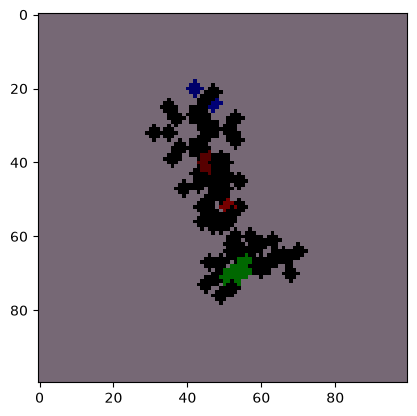

In [19]:
from matplotlib import pyplot as plt
img = images[0, 0].float()
plt.imshow(img.permute(1, 2, 0))

In [2]:
print(labels.shape)
print(images.shape)

torch.Size([11705, 20])
torch.Size([11705, 20, 3, 100, 100])


In [3]:
mean = images.mean(dim=(0,1,3,4))
std = images.std(dim=(0,1,3,4))
images = (images - mean[None,None,:,None,None]) / std[None,None,:,None,None] 


labels = labels[:,0]  #one label per molecule
labels = labels.long()

Ligand_train = torch.utils.data.TensorDataset(images, labels)
train_loader_Ligand = torch.utils.data.DataLoader(Ligand_train, batch_size = 64, shuffle = False)

In [73]:
#STAGE 2 : Creating the Model

class Net(nn.Module):     
    def __init__(self):   
        super().__init__() 
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)       
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)                               
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)    
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)     
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)    
        self.act3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(p=0.3)
        self.fc1 = nn.Linear(64 * 12 * 12, 128)                         
        self.act4 = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)   
    

    def forward(self, x):  
                
        batch_size, rotations, C, H, W = x.shape
        x = x.view(batch_size * rotations, C, H, W)
        x = self.pool1(self.act1(self.conv1(x)))
        x = self.pool2(self.act2(self.conv2(x)))
        x = self.pool3(self.act3(self.conv3(x)))
        x = x.view(-1, 64 * 12 * 12)
        x = self.act4(self.fc1(x))
        x = x.view(batch_size, rotations, -1)

        x = x.max(dim=1)[0]

        x = self.dropout(x)
        x = self.fc2(x)
        return x


In [6]:
#Loading Validation Data

#Data as Tensor
labels_val = torch.load("validation_labels.pt")
images_val = torch.load("validation_tensor.pt")


images_val = (images_val - mean[None,:,None,None]) / std[None,:,None,None] 

labels_val = labels_val.long()

Ligand_val = torch.utils.data.TensorDataset(images_val, labels_val)
val_loader_Ligand = torch.utils.data.DataLoader(Ligand_val, batch_size = 64, shuffle = False)


In [7]:
imgs, labels = next(iter(val_loader_Ligand))

print(imgs.shape)
print(labels.shape)



torch.Size([64, 20, 3, 100, 100])
torch.Size([64, 20])


In [8]:
from sklearn.metrics import roc_auc_score

def validate2(model,train_loader, val_loader):

    model.eval()

    true_labels = []
    pred_probs = []

    with torch.no_grad():

        for imgs, labels in val_loader:
   

            imgs = imgs.to(device)
            labels = labels.to(device)


            outputs = model(imgs)

            probs = torch.softmax(outputs, dim=1)[:,1]

            pred_probs.extend(probs.cpu().numpy())

            true_labels.extend(labels[:,0].cpu().numpy())

    auc = roc_auc_score(true_labels, pred_probs)

    print(f"Validation AUROC = {auc:.4f}")

    model.train()

In [9]:
#STAGE 3 : TRAINING LOOP

#Defining Training Loop
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    
    for epoch in range(1, n_epochs + 1):  
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train = loss_train + loss.item() 


        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))  
        if epoch == 1  or   epoch % 5 == 0:
            validate2(model, train_loader_Ligand, val_loader_Ligand)
            torch.save(model.state_dict(), "ligand_model4.pt")
    
            
    
      

#Define Variables
train_loader = train_loader_Ligand
model4 = Net().to(device) 
print(device)
optimizer = optim.SGD(model4.parameters(), lr=1e-2) 
weights = torch.tensor([1.0, 40.0], dtype=torch.float32).to(device)
loss_fn = nn.CrossEntropyLoss(weight=weights)  

#Run Training Loop
training_loop(n_epochs = 50,
    optimizer = optimizer,
    model = model4,
    loss_fn = loss_fn,
    train_loader = train_loader_Ligand)


mps
2026-07-22 09:36:49.971574 Epoch 1, Training loss 0.07448804403319344
Validation AUROC = 0.6816
Validation AUROC = 0.8158
2026-07-22 09:51:12.592882 Epoch 10, Training loss 0.09064665491262684
Validation AUROC = 0.8319
Validation AUROC = 0.8378
2026-07-22 10:09:11.293739 Epoch 20, Training loss 0.08728378569030412
Validation AUROC = 0.8368
Validation AUROC = 0.8266


KeyboardInterrupt: 

In [23]:
#Loading Model
model4 = Net().to(device)
model4.load_state_dict(torch.load("ligand_model4.pt"))
model4.eval()


Net(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (act3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (act4): ReLU()
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

In [75]:
model4.load_state_dict(torch.load("ligand_model4.pt"))
model4.eval()

# Get the first ligand molecule
images, labels = Ligand_val[0]

# Add batch dimension and move to device
images = images.unsqueeze(0).to(device)   # (1, 20, 3, 100, 100)

# One label per molecule
label = labels[0].item()

with torch.no_grad():
    output = model4(images)

prediction = output.argmax(dim=1).item()

print("Prediction:", prediction)
print("True label:", label)




Prediction: 0
True label: 0


In [71]:
import torch
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):         #takes trained cnn and last convolutional layer, since it retains spatial info and captures high level features    
        self.model = model
        self.target_layer = target_layer

        self.activations = None  #stores feature maps
        self.gradients = None    #stores gradients

        self.forward_hook = target_layer.register_forward_hook(    #saves the feature map after forward pass
            self.save_activation
        )

        self.backward_hook = target_layer.register_full_backward_hook(     #saves the gradients during backpropagation
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx=None):       #generates heatmap

        self.model.eval()                       #turns off dropout for evaluation purposes

        
        # Forward pass
        output = self.model(x)

        if class_idx is None:                    
            class_idx = output.argmax(dim=1).item()    #choose target class - (which classification has model predicted)

        self.model.zero_grad()               #zero gradients

        # Backprop for chosen class
        output[:, class_idx].backward()       

        activations = self.activations       #save
        gradients = self.gradients

        # Number of rotations
        n_rotations = x.shape[1]

        heatmaps = []

        for r in range(n_rotations):     #loop over rotations for the selected image
 
            act = activations[r].unsqueeze(0)   #extract  feature maps and gradients
            grad = gradients[r].unsqueeze(0)

            # Global Average Pooling
            weights = grad.mean(dim=(2,3), keepdim=True)  #average importance of feature map k, 

            # Weighted sum
            cam = (weights * act).sum(dim=1)    #each feature map is multiplied by its importance and then summed

            # ReLU
            cam = F.relu(cam)     #discarding negative contirbutions as they contirbute to evidence against the class

            # Resize to original image size
            cam = F.interpolate(
                cam.unsqueeze(1),
                size=(100,100),    #DEPENDING ON PIXELS
                mode='bilinear',
                align_corners=False
            )

            cam = cam.squeeze()

            # Normalize
            cam -= cam.min()

            if cam.max() > 0:
                cam /= cam.max()

            heatmaps.append(cam.detach().cpu().numpy())

        return heatmaps

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

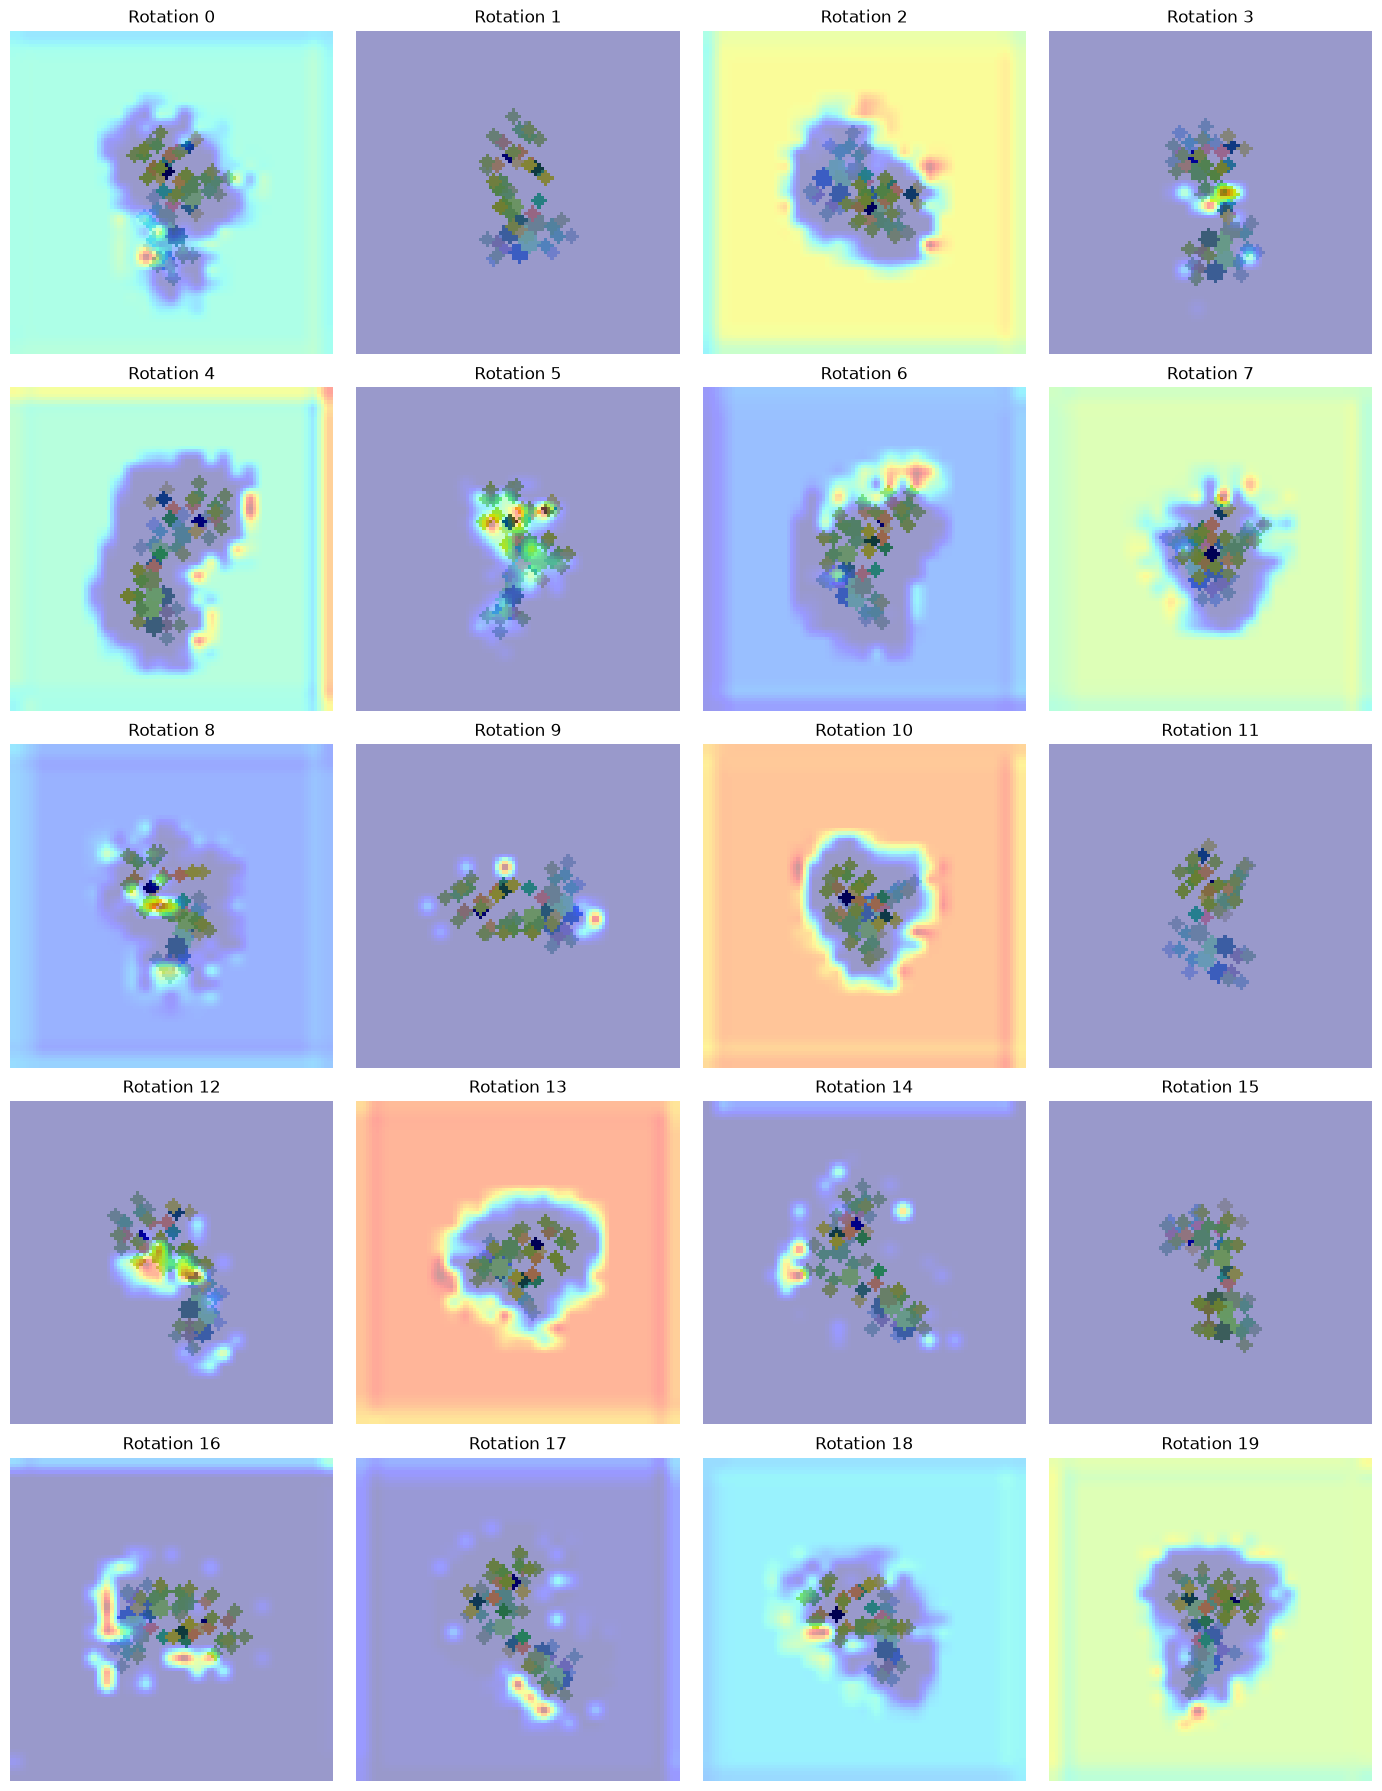

In [72]:
gradcam = GradCAM(model4, model4.conv3)
heatmaps = gradcam.generate(sample)
target_layer = model4.conv3
device = sample.device
mean = mean.to(device)
std = std.to(device)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 4, figsize=(14,18))

for r, ax in enumerate(axes.flat):

    img = sample[0, r]
    img = img * std[:,None,None] + mean[:,None,None]
    
    img = img.permute(1,2,0).cpu().numpy()

    ax.imshow(img)
    ax.imshow(heatmaps[r], cmap='jet', alpha=0.4)
    
    ax.set_title(f"Rotation {r}")
    ax.axis('off')

plt.tight_layout()
plt.show()